In [31]:
from MA_diffrax import *

import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import diffrax as dfrx
import equinox as eqx
import pymc as pm
from pymc.sampling.jax import sample_numpyro_nuts, sample_blackjax_nuts, get_jaxified_logp
from pytensor.link.jax.dispatch import jax_funcify
import matplotlib.pyplot as plt

from jax import random
import arviz as az
import sys, argparse, json, os

plt.style.use('custom')
mpl.rcParams['figure.autolayout'] = True

sys.path.append("../ampk_models/")
sys.path.append("../ampk_models/models")
from utils import *

from SALib import ProblemSpec, analyze

In [18]:
model = 'MA'
rhs = eval(model + '()')
rhs = dfrx.ODETerm(rhs)

solver = dfrx.Kvaerno5()
dt0=1e-12

rtol=1e-9
atol=1e-9
pcoeff=0.3
icoeff=0.4
stepsize_controller=dfrx.PIDController(rtol, atol, pcoeff=pcoeff, icoeff=icoeff)
t0 = 0.0
times = np.linspace(0, 25, 200)
t1 = times[-1]
saveat=dfrx.SaveAt(ts=times)

y0=jnp.array([0.195,1.0,0.0,0.0])

@jax.jit
def simulator(params):
    # solve model
    sol = dfrx.diffeqsolve(rhs, solver, t0=t0, t1=t1, dt0=dt0, 
    y0=y0, args=params, saveat=saveat,
    stepsize_controller=stepsize_controller,
    max_steps=10000000, throw=True)
    sol = jnp.squeeze(sol.ys)

    # compute ratio product/(total substrate + product)
    # at final time point
    result = sol[-1,3]/0.195

    return result

sim_vmap = jax.vmap(simulator, in_axes=(0,))

In [19]:
simulator(jnp.array([0.1, 0.025, 1.0]))  # Example call to the simulator

Array(0.90136405, dtype=float64)

In [43]:
sp = ProblemSpec({
        "names": ["k_f", "k_r", "k_cat"],
        "bounds": [[0.05, 0.5],
                   [0.0025, 0.25],
                   [0.1, 10.0]],
        "outputs": ["Y"],
    })

# generate samples
sp.sample_sobol(1024)

# use jac vmap to compute the simulator for all samples
sols = sim_vmap(sp.samples)

# analyze the results
sobol = analyze.sobol.analyze(sp, sols)

Text(0.5, 1.0, 'Sobol Sensitivity Analysis')

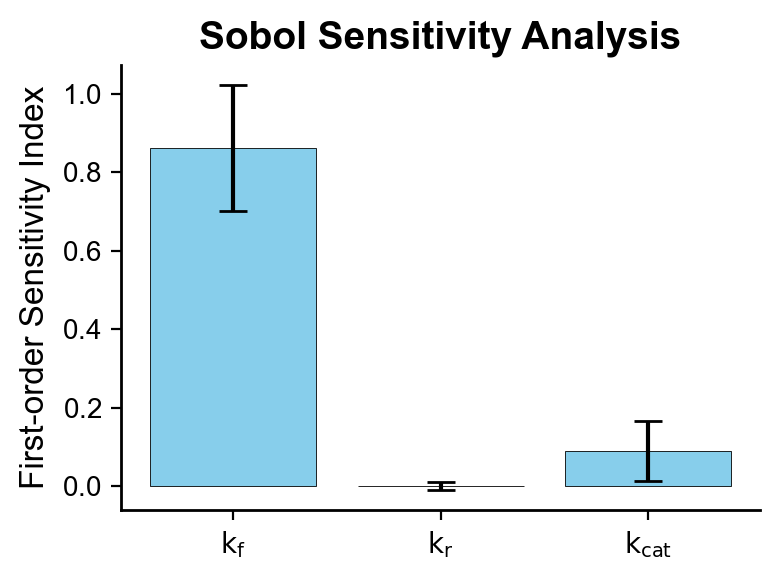

In [44]:
# Extract data
s1 = sobol['S1']
s1_conf = sobol['S1_conf']
names = sp['names']

# Plot
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar([r'$k_f$', r'$k_r$', r'$k_{cat}$'], s1, yerr=s1_conf, capsize=5, color='skyblue', edgecolor='black')
# ax.set_xlabel('Parameters')
ax.set_ylabel('First-order Sensitivity Index')
ax.set_title('Sobol Sensitivity Analysis', fontsize=14)
# ax.set_xticklabels(, rotation=45, ha='right')